### USAF Test

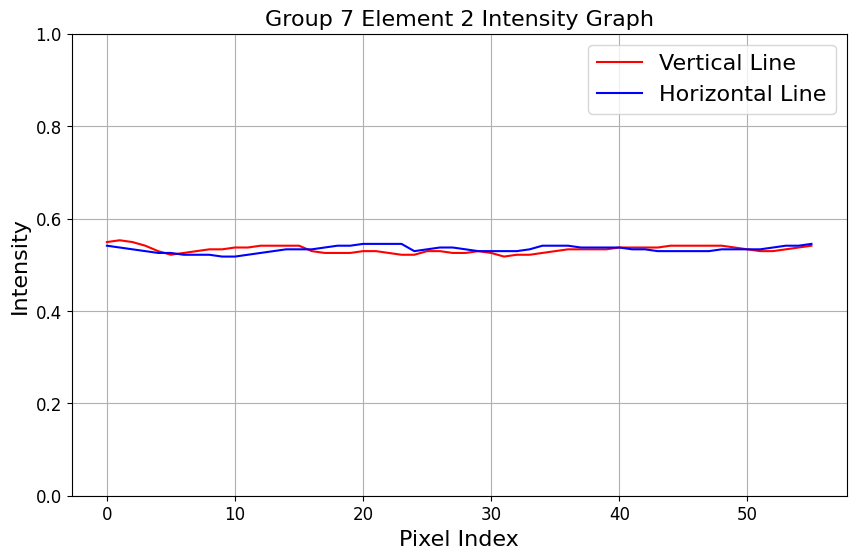

In [2]:
import cv2
import matplotlib.pyplot as plt

# Load the image
img_vertical = cv2.imread("Captures/data_3040/USAF_45v_G7E2.jpg", cv2.IMREAD_GRAYSCALE)
img_horizontal = cv2.imread("Captures/data_3040/USAF_45h_G7E2.jpg", cv2.IMREAD_GRAYSCALE)

# Select a single line (e.g., the middle line of the image)
line_index_vertical = img_vertical.shape[0] // 2
intensity_values_vertical = img_vertical[line_index_vertical, :]
intensity_values_vertical = intensity_values_vertical/255

line_index_horizontal = img_horizontal.shape[1] // 2
intensity_values_horizontal = img_horizontal[:, line_index_horizontal]
intensity_values_horizontal = intensity_values_horizontal/255

# Plot the intensity graph
plt.figure(figsize=(10, 6))
plt.plot(intensity_values_vertical, color='red', label='Vertical Line')
plt.plot(intensity_values_horizontal, color='blue', label='Horizontal Line')
plt.ylim(0, 1)  # Set y-axis limits to match intensity range
plt.legend(fontsize=16)
# plt.xlim(0, img_vertical.shape[1])  # Set x-axis limits to match image width
plt.title('Group 7 Element 2 Intensity Graph', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Pixel Index', fontsize=16)
plt.ylabel('Intensity', fontsize=16)
plt.grid()
plt.show()

### Slanted Edge MTF

Berhasil memuat gambar: Captures/data_3040/Slanted_45_50-0.15.jpg
Menggunakan ROI yang ditentukan pengguna: (1360, 0, 380, 3040)
Regresi linear untuk sudut: slope=-0.0881, R-squared=0.9995
Estimasi Sudut Tepi: 95.04 derajat (dari sumbu X, CCW)
ESF dihitung dengan 2578 titik. Lebar bin aktual: 0.2500 piksel.
MTF50: 0.0205 siklus/piksel


C:\Users\chris\AppData\Local\Temp\ipykernel_10284\4022884320.py:223: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_abs_lsf = np.trapz(np.abs(lsf), dx=esf_x_bin_width)


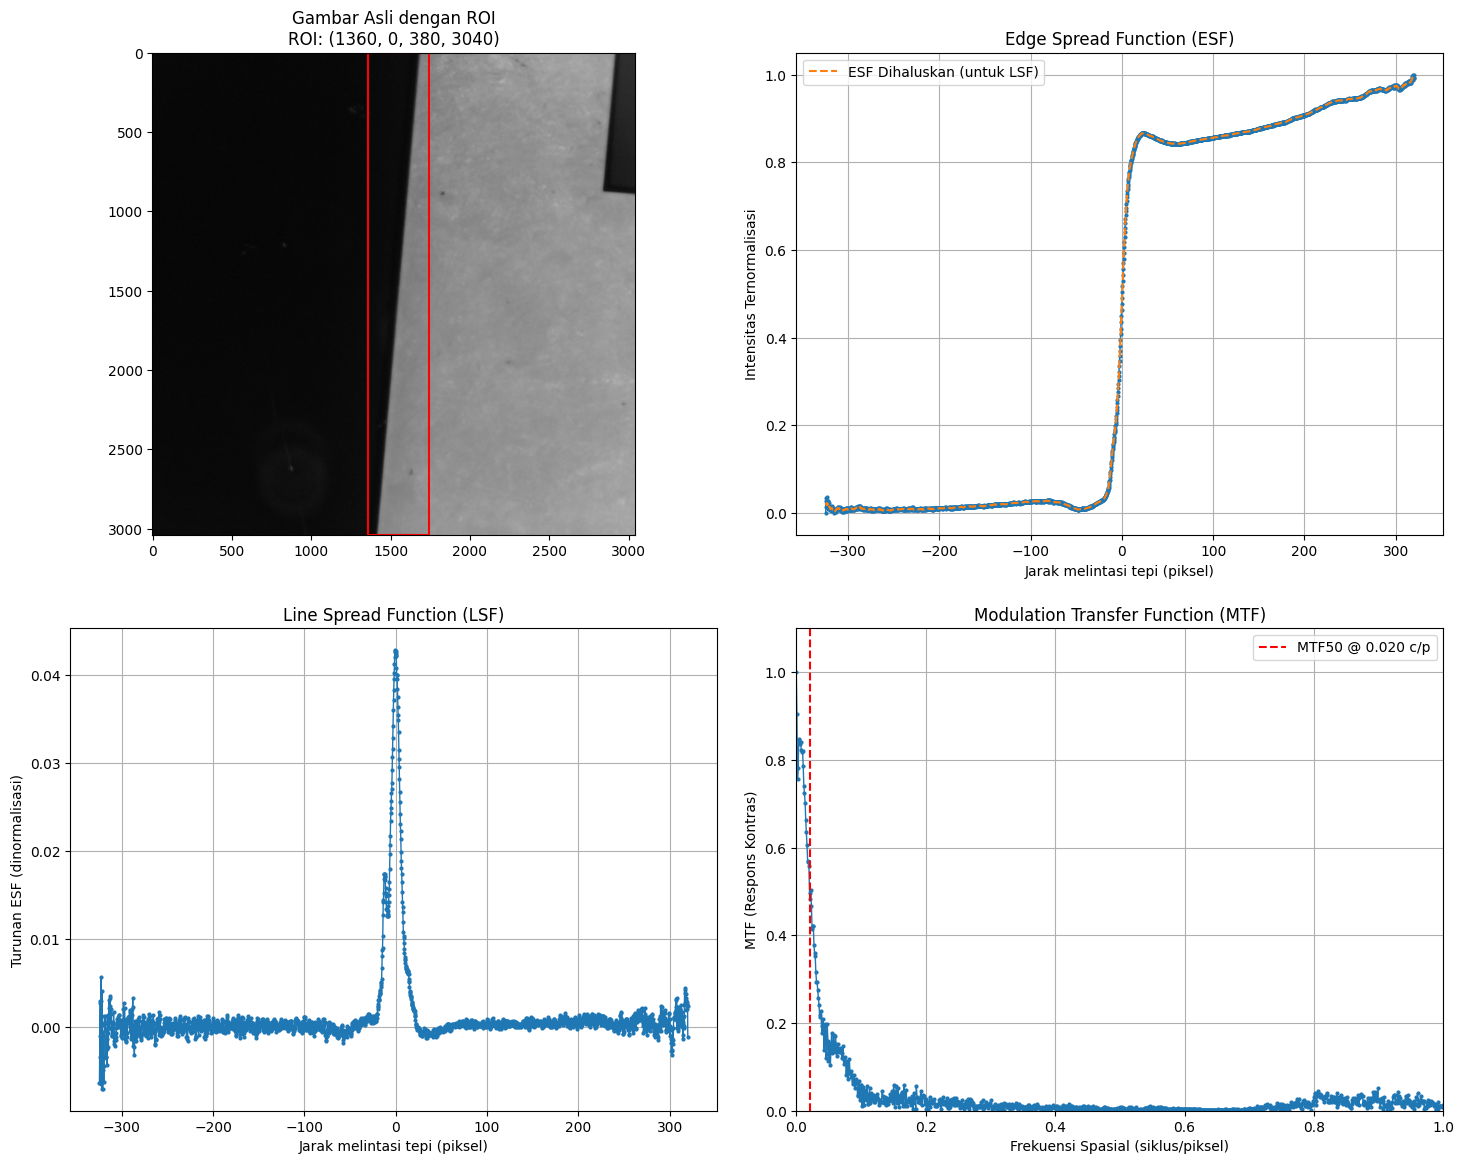

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d
import scipy.ndimage # Untuk gaussian_filter1d

# --- Konfigurasi ---
# PENGGUNA HARUS MENYESUAIKAN ROI_COORDS untuk gambar mereka!
# Format: (x_start, y_start, width, height) dari pojok kiri atas gambar.
ROI_COORDS = (1360, 0, 380, 3040) # Contoh ROI, sesuaikan dengan gambar Anda

SUPERSAMPLE_FACTOR = 4          # Faktor super-sampling (biasanya 4 atau 8)
LSF_SMOOTH_WINDOW = 11          # Jendela filter Savitzky-Golay untuk LSF (bilangan ganjil)
LSF_SMOOTH_POLYORDER = 3        # Orde polinomial filter Savitzky-Golay
N_FFT_POINTS = 4096            # Jumlah titik untuk FFT (disarankan pangkat 2)
TARGET_MTF_VAL = 0.5            # Untuk perhitungan MTF50 (misalnya)
MIN_CONTRAST_FOR_EDGE_DETECTION = 15 # Threshold kontras minimum untuk deteksi tepi per baris/kolom

# --- Fungsi Pembantu ---

def get_roi(image, roi_coords):
    """Mengekstrak Region of Interest (ROI) dari gambar."""
    x, y, w, h = roi_coords
    roi = image[y:y+h, x:x+w]
    if roi.size == 0:
        raise ValueError(f"ROI yang dipilih kosong. Periksa ROI_COORDS: {roi_coords} dan dimensi gambar.")
    return roi

def estimate_edge_angle(roi_gray):
    """Mengestimasi sudut kemiringan tepi dominan dalam ROI."""
    if roi_gray is None or roi_gray.size == 0:
        raise ValueError("ROI kosong atau tidak valid untuk estimasi sudut.")
    if roi_gray.ndim != 2:
        raise ValueError("ROI harus dalam format grayscale.")

    h, w = roi_gray.shape
    edge_points_x = [] # Menyimpan koordinat x (kolom) dari titik tepi
    edge_points_y = [] # Menyimpan koordinat y (baris) dari titik tepi

    # Heuristik sederhana untuk menentukan orientasi tepi (lebih vertikal atau horizontal)
    # Bisa ditingkatkan dengan analisis gradien global
    # Jika ROI lebih tinggi daripada lebar, asumsikan tepi lebih vertikal
    is_likely_vertical = h > w 

    if is_likely_vertical: # Tepi cenderung vertikal, pindai per baris
        for r_idx in range(h):
            row_data = roi_gray[r_idx, :].astype(float)
            # Haluskan data baris untuk mengurangi noise sebelum diferensiasi
            smoothed_row = scipy.ndimage.gaussian_filter1d(row_data, sigma=1)
            
            # Periksa apakah ada kontras yang cukup di baris ini
            if np.ptp(smoothed_row) < MIN_CONTRAST_FOR_EDGE_DETECTION:
                continue 
            
            diff_row = np.gradient(smoothed_row)
            if np.any(np.abs(diff_row) > 1e-3): # Pastikan ada gradien
                # Temukan kolom dengan gradien absolut maksimum sebagai titik tepi
                # Metode yang lebih baik: estimasi sub-piksel (misal, fitting parabola)
                edge_col = np.argmax(np.abs(diff_row))
                edge_points_x.append(edge_col)
                edge_points_y.append(r_idx)
            
    else: # Tepi cenderung horizontal, pindai per kolom
        for c_idx in range(w):
            col_data = roi_gray[:, c_idx].astype(float)
            smoothed_col = scipy.ndimage.gaussian_filter1d(col_data, sigma=1)

            if np.ptp(smoothed_col) < MIN_CONTRAST_FOR_EDGE_DETECTION:
                continue

            diff_col = np.gradient(smoothed_col)
            if np.any(np.abs(diff_col) > 1e-3):
                edge_row = np.argmax(np.abs(diff_col))
                edge_points_x.append(c_idx)
                edge_points_y.append(edge_row)

    if len(edge_points_x) < 5: # Butuh minimal beberapa titik untuk regresi yang baik
        raise ValueError(f"Tidak cukup titik tepi ({len(edge_points_x)}) ditemukan untuk estimasi sudut. "
                         "Sesuaikan ROI, periksa kontras gambar, atau "
                         "turunkan MIN_CONTRAST_FOR_EDGE_DETECTION jika perlu.")

    edge_points_x = np.array(edge_points_x)
    edge_points_y = np.array(edge_points_y)
    
    # Lakukan regresi linear
    if is_likely_vertical:
        # Fit x = slope * y + intercept
        slope, intercept, r_value, _, _ = linregress(edge_points_y, edge_points_x)
        angle_with_y_axis = np.arctan(slope) # Sudut tepi dengan sumbu Y (vertikal)
        # Sudut tepi dengan sumbu X (phi), CCW dari sumbu X positif
        estimated_angle_rad = np.pi/2 - angle_with_y_axis 
    else: # Tepi cenderung horizontal
        # Fit y = slope * x + intercept
        slope, intercept, r_value, _, _ = linregress(edge_points_x, edge_points_y)
        estimated_angle_rad = np.arctan(slope) # Sudut tepi dengan sumbu X (phi)

    print(f"Regresi linear untuk sudut: slope={slope:.4f}, R-squared={r_value**2:.4f}")
    if r_value**2 < 0.85: # Periksa kualitas fit
         print("Peringatan: Nilai R-squared rendah untuk fit sudut tepi. Estimasi sudut mungkin kurang akurat.")
         
    # Persiapan parameter garis untuk proyeksi ESF (ax + by + c = 0)
    # Parameter ini relatif terhadap asal ROI (pojok kiri atas ROI)
    if is_likely_vertical: # Garis: x - slope*y - intercept = 0
        A, B, C_unnorm = 1.0, -slope, -intercept
    else: # Garis: -slope*x + y - intercept = 0
        A, B, C_unnorm = -slope, 1.0, -intercept
    
    norm_factor = np.sqrt(A**2 + B**2)
    if norm_factor < 1e-9: # Hindari pembagian dengan nol
        raise ValueError("Faktor normalisasi garis sangat kecil, kemungkinan tepi tidak valid.")
    line_params_normalized = (A/norm_factor, B/norm_factor, C_unnorm/norm_factor)

    return estimated_angle_rad, line_params_normalized

def calculate_esf(roi_gray, line_params_normalized, supersample_factor=4):
    """Menghitung Edge Spread Function (ESF) menggunakan proyeksi dan super-sampling."""
    if roi_gray is None or roi_gray.size == 0:
        raise ValueError("ROI kosong atau tidak valid untuk perhitungan ESF.")
    h, w = roi_gray.shape
    
    A_norm, B_norm, C_norm = line_params_normalized

    distances = [] # Jarak tegak lurus dari setiap piksel ke garis tepi
    intensities = [] # Intensitas piksel

    for r_idx in range(h): # r_idx adalah koordinat y lokal dalam ROI
        for c_idx in range(w): # c_idx adalah koordinat x lokal dalam ROI
            # Jarak d = A_norm * x_lokal + B_norm * y_lokal + C_norm
            dist = A_norm * c_idx + B_norm * r_idx + C_norm
            distances.append(dist)
            intensities.append(roi_gray[r_idx, c_idx])

    distances = np.array(distances)
    intensities = np.array(intensities)

    # Urutkan berdasarkan jarak
    sorted_indices = np.argsort(distances)
    distances_sorted = distances[sorted_indices]
    intensities_sorted = intensities[sorted_indices]

    # Binning untuk super-sampling
    min_dist = distances_sorted[0]
    max_dist = distances_sorted[-1]
    
    bin_width = 1.0 / supersample_factor # Lebar bin dalam satuan piksel asli
    num_bins = int(np.ceil((max_dist - min_dist) / bin_width))

    if num_bins < 10: # Perlu jumlah bin yang cukup untuk ESF yang baik
        raise ValueError(f"Jumlah bin ({num_bins}) terlalu sedikit untuk ESF. "
                         "Periksa ROI, kontras, atau supersample_factor.")

    esf_x_centers = np.linspace(min_dist + bin_width/2.0, 
                                min_dist + (num_bins - 0.5) * bin_width, 
                                num_bins)
    esf_y_sum = np.zeros(num_bins, dtype=float)
    bin_counts = np.zeros(num_bins, dtype=int)

    # Alokasikan piksel ke bin berdasarkan jaraknya
    # np.searchsorted lebih efisien daripada loop manual untuk mencari bin
    bin_edges = np.linspace(min_dist, min_dist + num_bins * bin_width, num_bins + 1)
    bin_indices = np.searchsorted(bin_edges, distances_sorted, side='right') - 1
    # Pastikan bin_indices berada dalam rentang yang valid [0, num_bins-1]
    bin_indices = np.clip(bin_indices, 0, num_bins - 1)
    
    for i in range(len(distances_sorted)):
        idx = bin_indices[i]
        esf_y_sum[idx] += intensities_sorted[i]
        bin_counts[idx] += 1

    # Hitung rata-rata intensitas per bin
    esf_y_avg = np.zeros(num_bins, dtype=float)
    valid_bin_mask = bin_counts > 0
    esf_y_avg[valid_bin_mask] = esf_y_sum[valid_bin_mask] / bin_counts[valid_bin_mask]
    
    # Interpolasi untuk mengisi bin kosong jika ada (opsional, tapi bisa membantu)
    if np.any(~valid_bin_mask) and np.sum(valid_bin_mask) > 1:
        print(f"Peringatan: {np.sum(~valid_bin_mask)} bin kosong ditemukan dalam ESF. Mencoba interpolasi.")
        interp_func = interp1d(esf_x_centers[valid_bin_mask], esf_y_avg[valid_bin_mask], 
                               kind='linear', fill_value="extrapolate")
        esf_y_avg = interp_func(esf_x_centers)

    # Normalisasi ESF ke rentang [0, 1]
    esf_y_min = np.min(esf_y_avg)
    esf_y_max = np.max(esf_y_avg)
    if esf_y_max > esf_y_min + 1e-6: # Hindari pembagian nol jika kontras sangat rendah
        esf_y_normalized = (esf_y_avg - esf_y_min) / (esf_y_max - esf_y_min)
    else: 
        print("Peringatan: ESF tidak memiliki kontras. LSF/MTF mungkin tidak berarti.")
        esf_y_normalized = np.zeros_like(esf_y_avg)

    return esf_x_centers, esf_y_normalized, bin_width

def calculate_lsf(esf_y, esf_x_bin_width, smooth_window=11, polyorder=3):
    """Menghitung Line Spread Function (LSF) dari ESF."""
    if len(esf_y) < smooth_window : 
        print(f"Peringatan: ESF memiliki ({len(esf_y)}) titik, kurang dari jendela penghalusan ({smooth_window}). "
              "Penghalusan mungkin tidak efektif atau dilewati.")
        # Jika terlalu sedikit poin, Savitzky-Golay akan error. Mungkin lewati smoothing atau gunakan metode lain.
        # Untuk kesederhanaan, jika terlalu sedikit, kita lewati smoothing.
        smoothed_esf_y = esf_y 
        if len(esf_y) < 2: # Butuh minimal 2 poin untuk np.gradient
             raise ValueError("ESF memiliki kurang dari 2 titik, tidak bisa menghitung LSF.")
    else:
        # Pastikan window_length ganjil dan lebih besar dari polyorder
        smooth_window = max(polyorder + 1 if (polyorder+1)%2==1 else polyorder+2, min(smooth_window, len(esf_y)-1 if (len(esf_y)-1)%2==1 else len(esf_y)-2 ))
        if smooth_window <= polyorder or smooth_window%2==0: # fallback if previous logic fails
             smooth_window = max(3, polyorder+1 if (polyorder+1)%2!=0 else polyorder+2)
             if smooth_window > len(esf_y): smooth_window = len(esf_y) - (1 if len(esf_y)%2==0 else 0)

        if smooth_window > len(esf_y) or smooth_window <= polyorder :
             print("Tidak bisa melakukan smoothing Savitzky-Golay dengan parameter saat ini. Melewati smoothing LSF.")
             smoothed_esf_y = esf_y
        else:
             smoothed_esf_y = savgol_filter(esf_y, window_length=smooth_window, polyorder=polyorder, mode='mirror')
    
    # Hitung turunan (gradient). esf_x_bin_width adalah dx.
    lsf = np.gradient(smoothed_esf_y, esf_x_bin_width)
    
    # Normalisasi LSF agar luas di bawah kurva (integral absolut) adalah 1
    # Ini adalah praktik umum, meskipun normalisasi MTF di MTF[0]=1 juga umum.
    integral_abs_lsf = np.trapz(np.abs(lsf), dx=esf_x_bin_width)
    if integral_abs_lsf > 1e-9 : 
        lsf_normalized = lsf / integral_abs_lsf
    else:
        print("Peringatan: Integral LSF sangat kecil. LSF mungkin nol.")
        lsf_normalized = lsf

    return lsf_normalized, smoothed_esf_y

def calculate_mtf(lsf, lsf_bin_width, n_fft_points=4096):
    """Menghitung Modulation Transfer Function (MTF) dari LSF."""
    if len(lsf) == 0:
        print("Peringatan: LSF kosong, tidak bisa menghitung MTF.")
        return np.array([]), np.array([])

    # Padding LSF untuk resolusi FFT yang lebih baik
    # Pusatkan LSF sebelum padding jika perlu, tapi untuk |FFT| tidak terlalu kritikal
    pad_len_total = n_fft_points - len(lsf)
    if pad_len_total < 0: 
        print(f"Peringatan: Panjang LSF ({len(lsf)}) lebih besar dari N_FFT_POINTS ({n_fft_points}). "
              "LSF akan dipotong.")
        lsf_padded = lsf[:n_fft_points]
    else:
        pad_before = pad_len_total // 2
        pad_after = pad_len_total - pad_before
        lsf_padded = np.pad(lsf, (pad_before, pad_after), 'constant')

    # Hitung MTF (magnitudo dari FFT)
    mtf_complex = np.fft.rfft(lsf_padded) # rfft untuk input real
    mtf_raw = np.abs(mtf_complex)

    # Normalisasi MTF sehingga MTF[0] = 1
    if mtf_raw[0] > 1e-9 : 
        mtf_normalized = mtf_raw / mtf_raw[0]
    else:
        print("Peringatan: MTF[0] sangat kecil. MTF mungkin tidak berarti.")
        mtf_normalized = mtf_raw 
    
    # Hitung sumbu frekuensi (siklus per piksel asli)
    # lsf_bin_width adalah interval sampling spasial dari LSF (dalam satuan piksel asli)
    frequencies = np.fft.rfftfreq(n_fft_points, d=lsf_bin_width)
    
    return frequencies, mtf_normalized

def find_freq_at_mtf_value(frequencies, mtf_values, target_mtf=0.5):
    """Mencari frekuensi di mana MTF mencapai nilai target (misalnya, MTF50)."""
    if len(mtf_values) == 0 or len(frequencies) == 0:
        return None
    if mtf_values[0] < target_mtf: # Jika MTF awal sudah di bawah target
        print(f"Peringatan: MTF awal ({mtf_values[0]:.2f}) sudah di bawah target ({target_mtf}).")
        return None 
        
    # Cari indeks pertama di mana MTF <= target_mtf
    indices_below_target = np.where(mtf_values <= target_mtf)[0]
    if len(indices_below_target) == 0:
        # MTF tidak pernah mencapai target_mtf dalam rentang frekuensi yang dihitung
        return None 
        
    first_idx_below = indices_below_target[0]

    if first_idx_below == 0: # MTF[0] <= target, bisa jadi masalah normalisasi atau kualitas sangat buruk
        return frequencies[0] 

    # Interpolasi linear untuk akurasi yang lebih baik
    # (f1, m1) adalah titik sebelum target, (f2, m2) adalah titik setelah/pada target
    f1, m1 = frequencies[first_idx_below - 1], mtf_values[first_idx_below - 1]
    f2, m2 = frequencies[first_idx_below], mtf_values[first_idx_below]

    if np.isclose(m1, m2): # Hindari pembagian nol jika segmen datar
        return f1 if target_mtf >=m2 else f2 
        
    freq_at_target = f1 + (f2 - f1) * (target_mtf - m1) / (m2 - m1)
    return freq_at_target

# --- Eksekusi Utama ---
if __name__ == "__main__":
    IMAGE_PATH = 'Captures/data_3040/Slanted_45_50-0.15.jpg' # GANTI DENGAN PATH GAMBAR ANDA

    try:
        # Untuk demonstrasi, coba buat gambar slanted edge sintetis jika file tidak ada
        try:
            image_orig = cv2.imread(IMAGE_PATH)
            if image_orig is None:
                raise FileNotFoundError # Akan ditangkap di bawah
            print(f"Berhasil memuat gambar: {IMAGE_PATH}")
        except FileNotFoundError:
            print(f"Peringatan: Gambar '{IMAGE_PATH}' tidak ditemukan.")
            print("Membuat gambar slanted edge sintetis untuk demonstrasi...")
            synth_h, synth_w = 256, 256
            synthetic_image = np.ones((synth_h, synth_w), dtype=np.uint8) * 220 # Area terang
            
            # Sudut kemiringan (derajat dari sumbu Y, misal 6 derajat)
            angle_deg_from_y = 6 
            angle_rad_from_y = np.deg2rad(angle_deg_from_y)
            
            # Tepi x = m*y + c
            slope_m = np.tan(angle_rad_from_y) 
            center_x_offset = synth_w / 3 # Posisi tengah tepi
            
            for r_idx in range(synth_h): # y
                # x_edge adalah posisi x dari tepi pada baris y (r_idx)
                x_edge = slope_m * (r_idx - synth_h/2) + center_x_offset
                synthetic_image[r_idx, 0:int(round(x_edge))] = 30 # Area gelap
            
            # Tambahkan sedikit blur agar tepi tidak sempurna (lebih realistis)
            image_gray = cv2.GaussianBlur(synthetic_image, (5,5), sigmaX=1.2, sigmaY=1.2)
            ROI_COORDS = (int(center_x_offset - 30) , int(synth_h/2 - 60), 60, 120) # ROI untuk gambar sintetis
            print(f"Menggunakan ROI sintetis: {ROI_COORDS}")

        # Jika gambar asli dimuat:
        if 'image_orig' in locals() and image_orig is not None:
            if image_orig.ndim == 3:
                image_gray = cv2.cvtColor(image_orig, cv2.COLOR_BGR2GRAY)
            else:
                image_gray = image_orig
            print(f"Menggunakan ROI yang ditentukan pengguna: {ROI_COORDS}")
        
        # Ekstrak ROI
        roi = get_roi(image_gray, ROI_COORDS)

        # Tampilkan gambar asli dengan ROI
        plt.figure(figsize=(15, 12)) # Ukuran figure lebih besar
        plt.subplot(2,2,1)
        plt.imshow(image_gray, cmap='gray', vmin=0, vmax=255)
        rect = plt.Rectangle((ROI_COORDS[0], ROI_COORDS[1]), ROI_COORDS[2], ROI_COORDS[3],
                             edgecolor='red', facecolor='none', linewidth=1.5)
        plt.gca().add_patch(rect)
        plt.title(f'Gambar Asli dengan ROI\nROI: {ROI_COORDS}')
        
        # 1. Estimasi Sudut Tepi
        estimated_angle_rad, line_params_norm = estimate_edge_angle(roi)
        estimated_angle_deg_from_x = np.rad2deg(estimated_angle_rad)
        print(f"Estimasi Sudut Tepi: {estimated_angle_deg_from_x:.2f} derajat (dari sumbu X, CCW)")
        # print(f"Parameter Garis (A,B,C ternormalisasi): {line_params_norm}")
    
        # 2. Hitung ESF
        esf_x_coords, esf_y_values, esf_actual_bin_width = calculate_esf(roi, line_params_norm, SUPERSAMPLE_FACTOR)
        print(f"ESF dihitung dengan {len(esf_x_coords)} titik. Lebar bin aktual: {esf_actual_bin_width:.4f} piksel.")
        
        plt.subplot(2,2,2)
        plt.plot(esf_x_coords, esf_y_values, '.-', markersize=4, linewidth=1)
        plt.title('Edge Spread Function (ESF)')
        plt.xlabel('Jarak melintasi tepi (piksel)')
        plt.ylabel('Intensitas Ternormalisasi')
        plt.grid(True)

        # 3. Hitung LSF
        lsf_values, smoothed_esf_for_lsf = calculate_lsf(esf_y_values, esf_actual_bin_width, 
                                                          LSF_SMOOTH_WINDOW, LSF_SMOOTH_POLYORDER)
        # Sumbu x untuk LSF sama dengan ESF
        lsf_x_coords = esf_x_coords
        
        # Plot ESF yang dihaluskan pada grafik ESF untuk perbandingan
        plt.subplot(2,2,2) # Kembali ke plot ESF
        plt.plot(esf_x_coords, smoothed_esf_for_lsf, '--', label='ESF Dihaluskan (untuk LSF)', linewidth=1.5)
        plt.legend()
        
        plt.subplot(2,2,3)
        plt.plot(lsf_x_coords, lsf_values, '.-', markersize=4, linewidth=1)
        plt.title('Line Spread Function (LSF)')
        plt.xlabel('Jarak melintasi tepi (piksel)')
        plt.ylabel('Turunan ESF (dinormalisasi)')
        plt.grid(True)

        # 4. Hitung MTF
        frequencies, mtf_normalized_values = calculate_mtf(lsf_values, esf_actual_bin_width, N_FFT_POINTS)
        
        plt.subplot(2,2,4)
        if len(frequencies) > 0 and len(mtf_normalized_values) > 0:
            plt.plot(frequencies, mtf_normalized_values, '.-', markersize=4, linewidth=1)
            # Batasi sumbu x MTF ke rentang yang umum (misalnya, hingga Nyquist asli atau sedikit lebih)
            # Frekuensi Nyquist dari sensor asli adalah 0.5 siklus/piksel.
            # Frekuensi maksimum dari data super-sample adalah SUPERSAMPLE_FACTOR / 2 siklus/piksel.
            display_max_freq = min(0.5 * SUPERSAMPLE_FACTOR, 1.0) # Tampilkan hingga 1.0 c/p atau maks data
            plt.xlim(0, display_max_freq)
        else:
            plt.text(0.5, 0.5, "MTF tidak dapat dihitung.", horizontalalignment='center', verticalalignment='center')

        plt.title('Modulation Transfer Function (MTF)')
        plt.xlabel('Frekuensi Spasial (siklus/piksel)')
        plt.ylabel('MTF (Respons Kontras)')
        plt.grid(True)
        plt.ylim(0, 1.1) # MTF biasanya antara 0 dan 1

        # 5. Hitung MTF50 (atau nilai target MTF lainnya)
        mtf_target_freq = find_freq_at_mtf_value(frequencies, mtf_normalized_values, TARGET_MTF_VAL)
        if mtf_target_freq is not None:
            mtf_val_percent = int(TARGET_MTF_VAL*100)
            print(f"MTF{mtf_val_percent}: {mtf_target_freq:.4f} siklus/piksel")
            plt.axvline(mtf_target_freq, color='r', linestyle='--', 
                        label=f'MTF{mtf_val_percent} @ {mtf_target_freq:.3f} c/p')
            plt.legend(loc='upper right')
        else:
            print(f"MTF{int(TARGET_MTF_VAL*100)} tidak dapat ditentukan (MTF mungkin tidak turun ke {TARGET_MTF_VAL}).")

        plt.tight_layout(pad=2.0) # Beri sedikit padding antar subplot
        plt.show()

    except FileNotFoundError as e:
        print(f"Kesalahan File: {e}")
        print("Pastikan variabel IMAGE_PATH sudah benar atau ada gambar sintetis yang dibuat.")
    except ValueError as e:
        print(f"Kesalahan Nilai: {e}")
        print("Ini bisa disebabkan oleh ROI yang tidak valid, kontras gambar rendah, atau parameter yang tidak sesuai.")
    except Exception as e:
        print(f"Terjadi kesalahan tak terduga: {e}")
        import traceback
        traceback.print_exc()

### DOF

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d, gaussian_filter
from scipy.signal import find_peaks
from scipy.interpolate import UnivariateSpline, interp1d, PchipInterpolator, InterpolatedUnivariateSpline
import numpy as np

def filter_significant_minima(profile, minima_idx, peaks_idx, min_depth=2, enforce_edge=True):
    significant_minima = []

    for i in minima_idx:
        # Cari puncak kiri dan kanan
        left_peaks = peaks_idx[peaks_idx < i]
        right_peaks = peaks_idx[peaks_idx > i]
        if len(left_peaks) == 0 or len(right_peaks) == 0:
            continue
        left_peak = left_peaks[-1]
        right_peak = right_peaks[0]
        
        local_max = min(profile[left_peak], profile[right_peak])
        depth = local_max - profile[i]
        if depth >= min_depth:
            significant_minima.append(i)

    # Tambahkan anchor point di ujung kiri dan kanan jika tidak ada titik dekat tepi
    if enforce_edge:
        if len(significant_minima) == 0 or significant_minima[0] > 5:
            significant_minima.insert(0, 0)
        if significant_minima[-1] < len(profile) - 5:
            significant_minima.append(len(profile) - 1)

    return np.array(significant_minima)

def measure_dof(lsf_profile, focus_threshold=0.8, baseline_threshold=0.1):
    # ===== BASELINE ====== #
    # Rata-rata Puncak
    sorted_profile = np.sort(lsf_profile_to_plot)
    # Ambil 10% nilai tertinggi dan hitung rata-ratanya
    top_10_percent_idx = int(len(sorted_profile) * (1-baseline_threshold))
    average_peak_intensity = np.mean(sorted_profile[top_10_percent_idx:])

    #===== MINIMA PEAKS ======#
    maxima, _ = find_peaks(lsf_profile)
    minima, _ = find_peaks(-lsf_profile)
    minima = filter_significant_minima(lsf_profile, minima, maxima, min_depth=5)
    minima_idx_list = minima
    minima_list = lsf_profile[minima]

    # global_minima = np.min(lsf_profile)
    # global_minima_idx = np.argmin(global_minima)

    # full_valley_depth = average_peak_intensity - global_minima
    # threshold_dof_intensity = global_minima + ((1-focus_threshold) * full_valley_depth)

    #===== ENVELOPE ======#
    # Interpolasi envelope menggunakan minima
    interp_func = interp1d(minima_idx_list, minima_list, kind='quadratic', fill_value='extrapolate')
    envelope = interp_func(np.arange(len(profile))) 
    global_minima = np.min(envelope)
    # Ambang 80% berdasarkan envelope
    full_valley_depth_envelope = average_peak_intensity - np.min(envelope)
    threshold_dof_intensity_envelope = np.min(envelope) + ((1-focus_threshold) * full_valley_depth_envelope)
    # Cari titik-titik pada envelope yang di bawah ambang
    below_threshold = np.where(envelope <= threshold_dof_intensity_envelope)[0]
    if len(below_threshold) < 2:
        return None
    
    return below_threshold, average_peak_intensity, threshold_dof_intensity_envelope, envelope, minima


Multiple DOF Measurement

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter, gaussian_filter1d

#========== Helper Functions ==========#
def filter_significant_minima(profile, minima_idx, peaks_idx, min_depth=2, enforce_edge=True):
    significant_minima = []

    for i in minima_idx:
        left_peaks = peaks_idx[peaks_idx < i]
        right_peaks = peaks_idx[peaks_idx > i]
        if len(left_peaks) == 0 or len(right_peaks) == 0:
            continue
        left_peak = left_peaks[-1]
        right_peak = right_peaks[0]
        
        local_max = min(profile[left_peak], profile[right_peak])
        depth = local_max - profile[i]
        if depth >= min_depth:
            significant_minima.append(i)

    if enforce_edge:
        if len(significant_minima) == 0 or (len(significant_minima) > 0 and significant_minima[0] > 5):
            significant_minima.insert(0, 0)
        # Ensure the last significant_minima is not already the edge before appending
        if len(significant_minima) == 0 or (len(significant_minima) > 0 and significant_minima[-1] < len(profile) - 5):
             # Check if the last element is already len(profile) - 1
            if len(significant_minima) == 0 or significant_minima[-1] != len(profile) - 1:
                significant_minima.append(len(profile) - 1)
        # Remove duplicates that might arise if 0 or len(profile)-1 were already present
        significant_minima = sorted(list(set(significant_minima)))
    return np.array(significant_minima)

def measure_dof(lsf_profile, focus_threshold=0.8, baseline_threshold=0.1, min_depth_for_filter=5):
    # ===== BASELINE ====== #
    sorted_profile = np.sort(lsf_profile) # Corrected: use lsf_profile argument
    top_10_percent_idx = int(len(sorted_profile) * (1 - baseline_threshold))
    average_peak_intensity = np.mean(sorted_profile[top_10_percent_idx:])

    #===== MINIMA PEAKS ======#
    maxima, _ = find_peaks(lsf_profile)
    minima_indices, _ = find_peaks(-lsf_profile) # Raw minima
    
    if len(maxima) == 0: # Handle cases with no distinct peaks for filtering context
         filtered_minima_idx = filter_significant_minima(lsf_profile, minima_indices, maxima, min_depth=min_depth_for_filter, enforce_edge=True)
    else:
        filtered_minima_idx = filter_significant_minima(lsf_profile, minima_indices, maxima, min_depth=min_depth_for_filter, enforce_edge=True)

    if len(filtered_minima_idx) < 2:
        print(f"Warning: Not enough significant minima ({len(filtered_minima_idx)}) found for profile. Returning None.")
        return None
        
    minima_values_at_filtered_indices = lsf_profile[filtered_minima_idx]

    #===== ENVELOPE ======#
    try:
        # Interpolate envelope using filtered minima
        interp_func = interp1d(filtered_minima_idx, minima_values_at_filtered_indices, kind='quadratic', fill_value='extrapolate')
        envelope = interp_func(np.arange(len(lsf_profile))) # Corrected: use len(lsf_profile)
    except ValueError as e:
        print(f"Error during interpolation for profile: {e}. Returning None.")
        return None

    global_minima_on_envelope = np.min(envelope) ################################### ENVELOPE
    # global_minima_on_envelope = np.min(lsf_profile)
    full_valley_depth_envelope = average_peak_intensity - global_minima_on_envelope
    
    # Ensure full_valley_depth_envelope is positive to avoid issues
    if full_valley_depth_envelope <= 0:
        print(f"Warning: Full valley depth on envelope is not positive ({full_valley_depth_envelope:.2f}). Check baseline or minima. Returning None.")
        return None

    threshold_dof_intensity_envelope = global_minima_on_envelope + ((1 - focus_threshold) * full_valley_depth_envelope)
    
    below_threshold_indices = np.where(envelope <= threshold_dof_intensity_envelope)[0] ############################ ENVELOPE
    # below_threshold_indices = np.where(lsf_profile <= threshold_dof_intensity_envelope)[0]
    
    if len(below_threshold_indices) < 1:
        print(f"Warning: Not enough points below DOF threshold ({len(below_threshold_indices)}). Returning None.")
        return None
    
    return below_threshold_indices, average_peak_intensity, threshold_dof_intensity_envelope, envelope, filtered_minima_idx


def compute_fwhm(profile):
    # Normalize profile
    profile_norm = profile - np.min(profile)
    if np.max(profile_norm) == 0: return None # Avoid division by zero if profile is flat
    profile_norm = profile_norm / np.max(profile_norm)
    half_max = 0.5
    indices = np.where(profile_norm >= half_max)[0]
    if len(indices) >= 2:
        return indices[-1] - indices[0]
    else:
        return None

def find_two_deepest_minima(profile, minima_indices_input):
    if len(minima_indices_input) < 1:
        return None # Not enough minima
    
    depths = profile[minima_indices_input]
    
    if len(minima_indices_input) == 1: # Only one minimum found
        return sorted([minima_indices_input[0], minima_indices_input[0]]) # Return it twice, or handle as error

    # Find index of the global minimum among the provided minima_indices_input
    global_min_val_idx_in_depths = np.argmin(depths)
    global_min_actual_idx = minima_indices_input[global_min_val_idx_in_depths]
    diffs = np.abs(minima_indices_input - global_min_actual_idx).astype(float)
    diffs[diffs == 0] = np.inf  # Avoid selecting the global_min_actual_idx itself
    
    if np.all(np.isinf(diffs)): # Only one unique minimum was effectively passed or became global_min_actual_idx
        print("Warning: Could not find a distinct neighbor for the deepest minimum.")
        return None 

    neighbor_actual_idx = minima_indices_input[np.argmin(diffs)]
    
    return sorted([global_min_actual_idx, neighbor_actual_idx])

def analyze_and_plot_dof_at_y(image_display, lsf_profile, y_value, 
                              real_distance_mm_calib, focus_thresh, 
                              baseline_thresh, min_depth_val,
                              line_color='red', plot_title_prefix=""):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))
    # fig.suptitle(f"{plot_title_prefix}DOF Analysis at Y = {y_value}", fontsize=16)

    # --- Plot Image ---
    ax1.imshow(image_display, cmap='gray', extent=[0, image_display.shape[1], image_display.shape[0], 0])
    ax1.set_title("Calibration Slide Image")
    ax1.axis('on') # Keep axis for context if needed, or 'off'
    ax1.axhline(y_value, color=line_color, linestyle='--', linewidth=2,
                label=f'LSF taken at y={y_value}')
    ax1.legend(loc="upper right")

    # --- Measure DOF ---
    measurement_result = measure_dof(lsf_profile, 
                                     focus_threshold=focus_thresh, 
                                     baseline_threshold=baseline_thresh,
                                     min_depth_for_filter=min_depth_val)

    if measurement_result is None:
        ax2.plot(lsf_profile, color='black')
        ax2.set_title(f'LSF at y = {y_value} (Could not determine DOF)')
        ax2.text(0.5, 0.5, "DOF calculation failed.\nNot enough significant minima or other issue.",
                 horizontalalignment='center', verticalalignment='center',
                 transform=ax2.transAxes, color='red', fontsize=12,
                 bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
        ax2.set_xlabel("X Position (pixel)")
        ax2.set_ylabel("Intensity")
        ax2.grid(True)
        ax2.set_xlim(0, len(lsf_profile))
        plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to make space for suptitle
        plt.show()
        print(f"Could not determine DOF for y={y_value}.")
        return

    below_threshold, average_peak_intensity, threshold_dof_intensity, envelope, minima_idx_list_from_dof = measurement_result
    
    if len(minima_idx_list_from_dof) < 2: # Check again after measure_dof, though measure_dof should handle it
        print(f"Warning: Not enough minima from measure_dof for y={y_value} for calibration.")
        # Plot basic LSF if calibration part fails
        ax2.plot(lsf_profile, color='black', label='LSF')
        ax2.plot(envelope, color='orange', linestyle='--', linewidth=1.5, label='Envelope') ######################################### ENVELOPE
        ax2.axhline(average_peak_intensity, color='blue', linestyle=':', linewidth=2, label=f'Avg. Top 10% Max ({average_peak_intensity:.2f})')
        if envelope is not None : ax2.axhline(np.min(envelope), color='red', linestyle=':', linewidth=2, label=f'Global Minima (Env) ({np.min(envelope):.2f})') ################
        ax2.axhline(threshold_dof_intensity, color='green', linestyle=':', linewidth=2, label=f'DOF Threshold ({threshold_dof_intensity:.2f})')
        ax2.set_title(f'LSF at y = {y_value} (Calibration failed)')
        ax2.legend()
        ax2.grid(True)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()
        return

    # --- Calibration based on two deepest/closest significant minima ---
    # Use the minima_idx_list returned by measure_dof as it has passed filtering.
    deepest_minima_pair = find_two_deepest_minima(lsf_profile, minima_idx_list_from_dof)
    
    if deepest_minima_pair is None or len(deepest_minima_pair) < 2 :
        print(f"Could not find two distinct deepest minima for calibration at y={y_value}.")
        # Fallback or simple plot
        pixel_distance_calib = "N/A"
        scale_mm_per_pixel_val = "N/A"
        dof_width_mm_val = "N/A"
    else:
        pixel_distance_calib = abs(deepest_minima_pair[1] - deepest_minima_pair[0])
        if pixel_distance_calib == 0: # Avoid division by zero if minima are the same point
            print(f"Warning: Calibration pixel distance is zero at y={y_value}. Cannot calculate scale.")
            scale_mm_per_pixel_val = "N/A"
            dof_width_mm_val = "N/A"
        else:
            scale_mm_per_pixel_val = real_distance_mm_calib / pixel_distance_calib
            dof_pixel_width = abs(below_threshold[-1] - below_threshold[0])
            dof_width_mm_val = dof_pixel_width * scale_mm_per_pixel_val

    # --- Plot LSF and DOF Info ---
    ax2.plot(lsf_profile, color='black', label='LSF Profile')
    ax2.set_xlabel("X Position (pixel)")
    ax2.set_ylabel("Intensity")
    ax2.grid(True)
    ax2.set_xlim(0, len(lsf_profile))
    ax2.set_title(f'LSF Analysis at y = {y_value}')

    # ax1.axvline(below_threshold[0], color='purple', linestyle=':', linewidth=2, label=f'DOF Start ({below_threshold[0]})')
    # ax1.axvline(below_threshold[-1], color='purple', linestyle=':', linewidth=2, label=f'DOF End ({below_threshold[-1]})')
    # ax2.axvline(below_threshold[0], color='purple', linestyle=':', linewidth=2, label=f'DOF Start ({below_threshold[0]})')
    # ax2.axvline(below_threshold[-1], color='purple', linestyle=':', linewidth=2, label=f'DOF End ({below_threshold[-1]})')
    
    ############################################################################## ENVELOPE
    if envelope is not None:
        global_minima_on_envelope = np.min(envelope)
        ax2.plot(envelope, color='orange', linestyle='--', linewidth=1.5, label='Envelope')
        ax2.axhline(global_minima_on_envelope, color='red', linestyle=':', linewidth=2, label=f'Global Minima (Env) ({global_minima_on_envelope:.2f})')
    # global_minima_on_profile = np.min(lsf_profile) # Use profile directly for global minima
    # ax2.axhline(global_minima_on_profile, color='red', linestyle=':', linewidth=2, label=f'Global Minima (Env) ({global_minima_on_profile:.2f})')   
    
    ax2.axhline(average_peak_intensity, color='blue', linestyle=':', linewidth=2, label=f'Avg. Top 10% Max LSF ({average_peak_intensity:.2f})')
    ax2.axhline(threshold_dof_intensity, color='green', linestyle=':', linewidth=2, label=f'80% DOF Threshold ({threshold_dof_intensity:.2f})')

    # LITE VERSION
    ax1.axvline(below_threshold[0], color='purple', linestyle=':', linewidth=2)
    ax1.axvline(below_threshold[-1], color='purple', linestyle=':', linewidth=2)
    ax2.axvline(below_threshold[0], color='purple', linestyle=':', linewidth=2, label=f"Left DOF Border: {below_threshold[0]:.2f}")
    ax2.axvline(below_threshold[-1], color='purple', linestyle=':', linewidth=2, label=f"Right DOF Border: {below_threshold[-1]:.2f}")

    
    # Plot identified minima points used for envelope
    # ax2.plot(minima_idx_list_from_dof, lsf_profile[minima_idx_list_from_dof], 'x', color='cyan', markersize=8, label='Significant Minima')

    # if deepest_minima_pair and len(deepest_minima_pair) == 2:
    #      ax2.plot(deepest_minima_pair, lsf_profile[deepest_minima_pair], 'o', color='magenta', markersize=6, label='Calibration Minima')


    info_text_parts = []
    # if isinstance(pixel_distance_calib, (int, float)):
        # info_text_parts.append(f"Calib. Minima Dist (px): {pixel_distance_calib}")
    # if isinstance(scale_mm_per_pixel_val, (int, float)):
        # info_text_parts.append(f"Scale: {scale_mm_per_pixel_val:.4f} mm/pixel")
    if isinstance(dof_width_mm_val, (int, float)):
        # info_text_parts.append(f"DOF Width: {dof_width_mm_val:.4f} mm")
        dof_pixel_width_val = abs(below_threshold[-1] - below_threshold[0])
        info_text_parts.append(f"DOF Width (px): {dof_pixel_width_val}")


    info_text = "\n".join(info_text_parts)

    ax2.text(0.98, 0.96, info_text,
             transform=ax2.transAxes,
             fontsize=9,
             va='top', ha='right',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
    
    ax2.legend(loc="lower center", bbox_to_anchor=(0.5, -0.35), ncol=3, fontsize='small') # Adjust legend position
    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to make space for suptitle and legend
    plt.show()

    if isinstance(dof_width_mm_val, (int, float)):
        print("^"*30)
        print(f"Results for y = {y_value}:")
        print(f"  Calibration Minima Distance (pixels): {pixel_distance_calib}")
        print(f"  Scale: {scale_mm_per_pixel_val:.4f} mm/pixel")
        print(f"  DOF Width: {dof_pixel_width_val:.4f} pixels")
        print(f"  DOF Width: {dof_width_mm_val:.4f} mm")
        print(f"Posisi Global Minima: {np.argmin(envelope):.0f}, {np.min(envelope):.2f}")
        print("-" * 30)



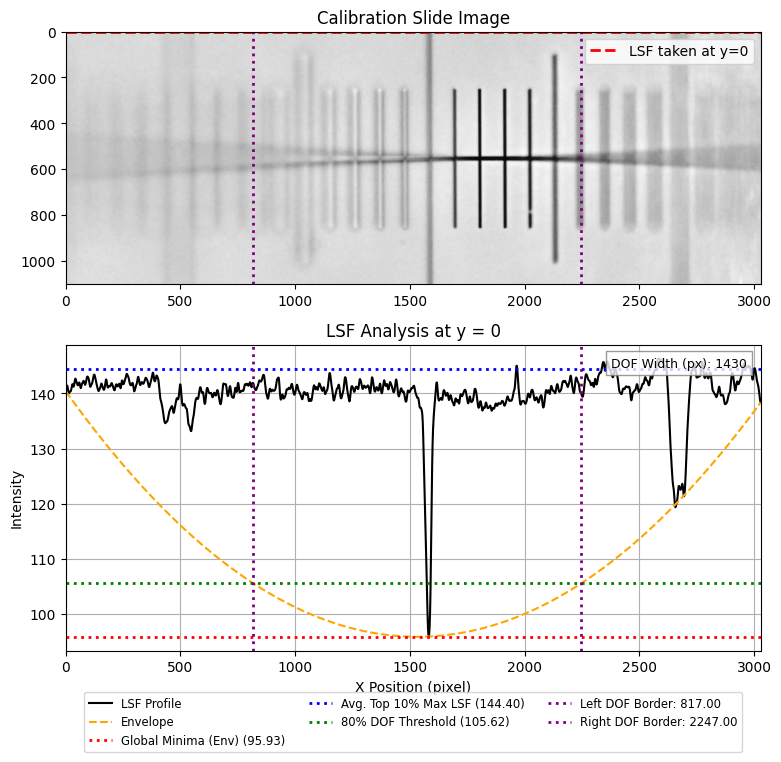

^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Results for y = 0:
  Calibration Minima Distance (pixels): 1447
  Scale: 0.0000 mm/pixel
  DOF Width: 1430.0000 pixels
  DOF Width: 0.0699 mm
Posisi Global Minima: 1532, 95.93
------------------------------


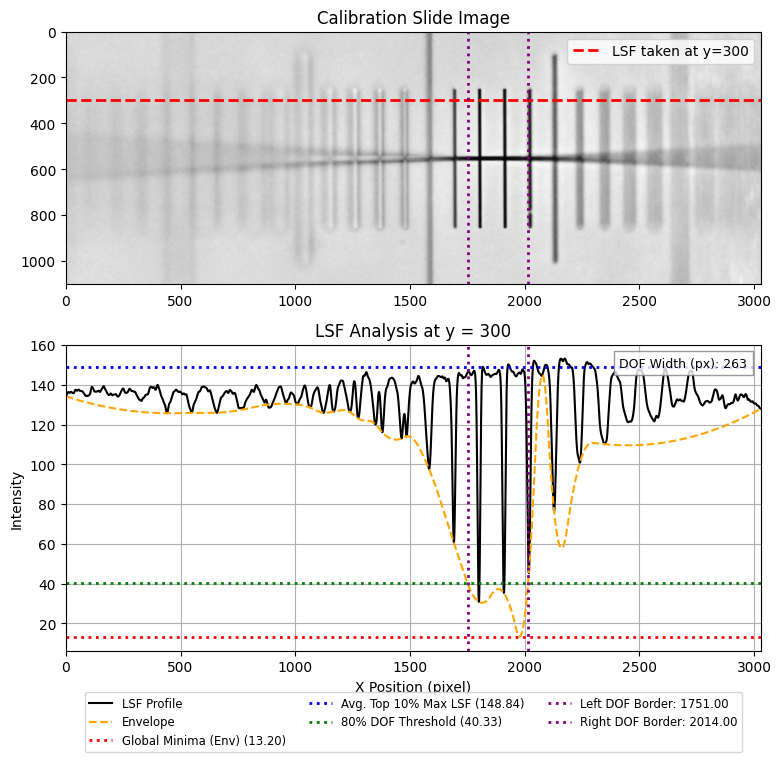

^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Results for y = 300:
  Calibration Minima Distance (pixels): 109
  Scale: 0.0006 mm/pixel
  DOF Width: 263.0000 pixels
  DOF Width: 0.1706 mm
Posisi Global Minima: 1977, 13.20
------------------------------


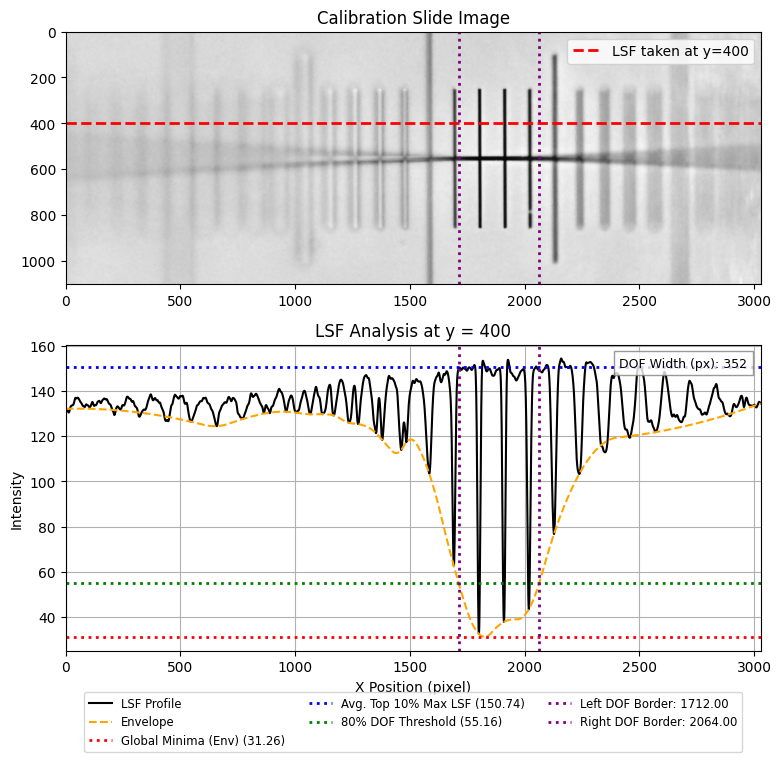

^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Results for y = 400:
  Calibration Minima Distance (pixels): 109
  Scale: 0.0006 mm/pixel
  DOF Width: 352.0000 pixels
  DOF Width: 0.2284 mm
Posisi Global Minima: 1825, 31.26
------------------------------


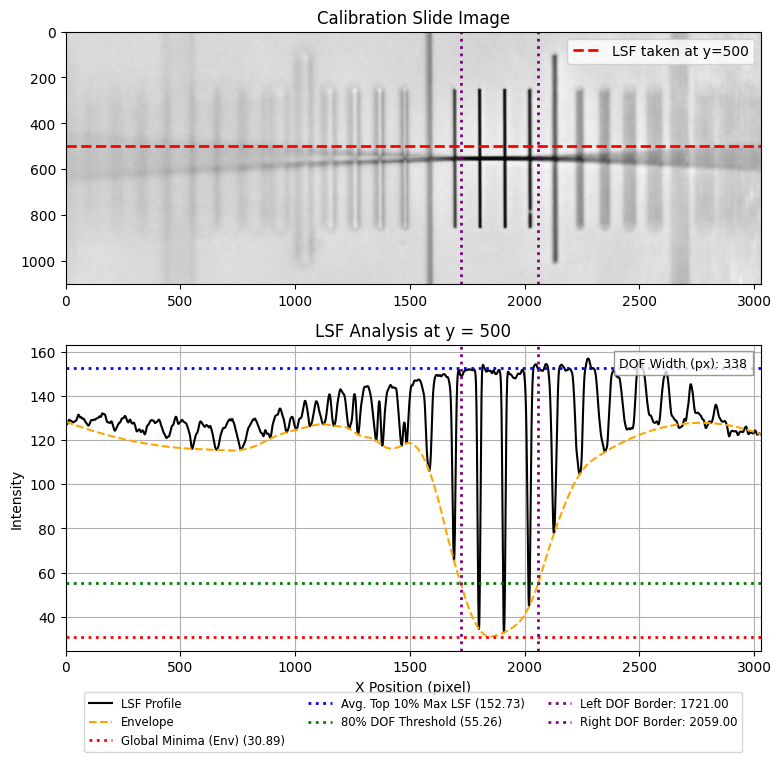

^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Results for y = 500:
  Calibration Minima Distance (pixels): 109
  Scale: 0.0006 mm/pixel
  DOF Width: 338.0000 pixels
  DOF Width: 0.2193 mm
Posisi Global Minima: 1850, 30.89
------------------------------


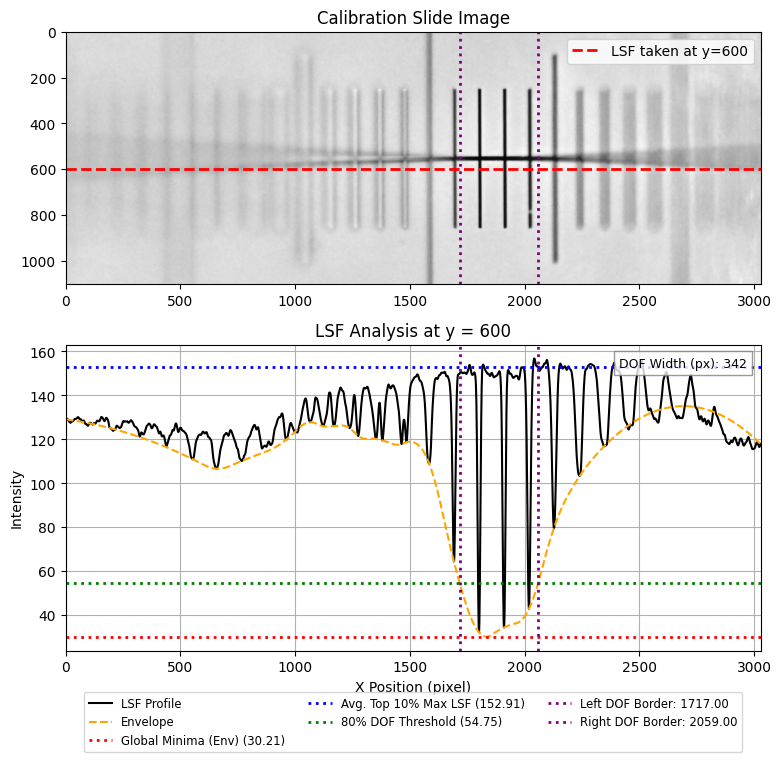

^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Results for y = 600:
  Calibration Minima Distance (pixels): 109
  Scale: 0.0006 mm/pixel
  DOF Width: 342.0000 pixels
  DOF Width: 0.2219 mm
Posisi Global Minima: 1835, 30.21
------------------------------


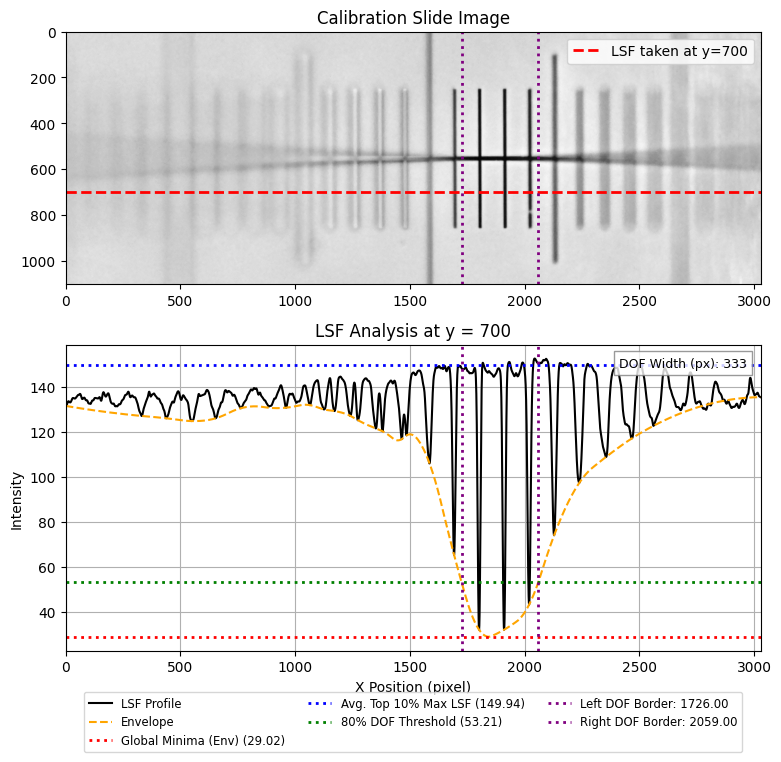

^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Results for y = 700:
  Calibration Minima Distance (pixels): 109
  Scale: 0.0006 mm/pixel
  DOF Width: 333.0000 pixels
  DOF Width: 0.2160 mm
Posisi Global Minima: 1844, 29.02
------------------------------


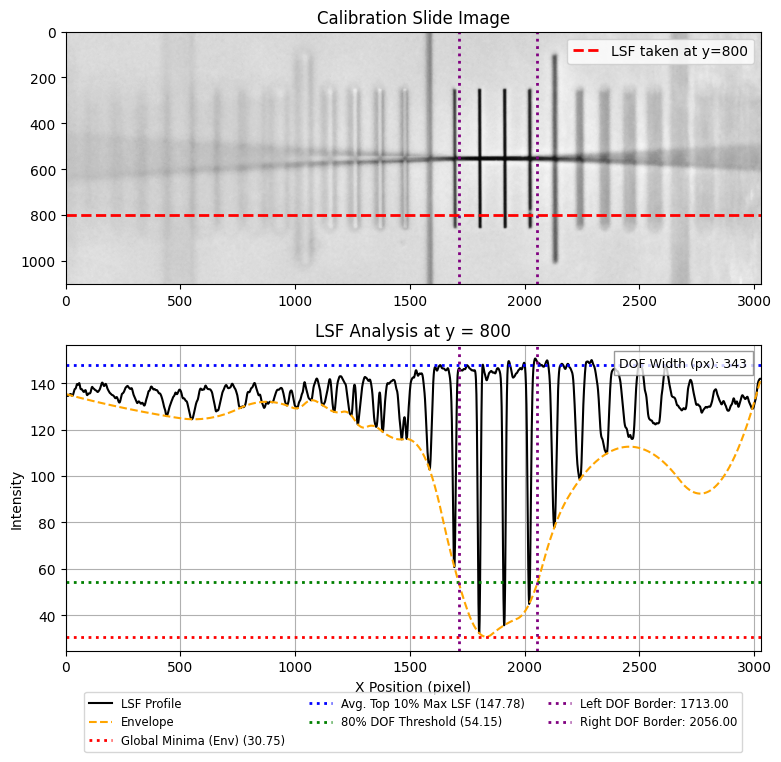

^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Results for y = 800:
  Calibration Minima Distance (pixels): 108
  Scale: 0.0007 mm/pixel
  DOF Width: 343.0000 pixels
  DOF Width: 0.2246 mm
Posisi Global Minima: 1832, 30.75
------------------------------


In [ ]:
# --- Main Script Execution ---
if __name__ == "__main__":
    # --- STEP 1: Load image ---
    image_path = "Captures/data_3040/ACC_Z/2.5x_0.1mm/8.jpg"
    # --- Define Y values to process and plot ---
    y_values_to_plot = [0, 300, 400, 500, 600, 700, 800] # 0 to ~1120

    # --- Calibration and Processing Parameters ---
    real_dist_mm = 0.1*((2**0.5)*0.5)  # Real distance between calibration lines (e.g., 0.1 mm)
    focus_param = 0.8   # Focus threshold for DOF
    baseline_param = 0.1 # Baseline threshold for peak intensity
    min_depth_minima_param = 5 # Min depth for significant minima filtering

    img_original = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img_float = img_original.astype(np.float32)

    # --- Koreksi Pencahayaan dengan Image Processing ---
    background_estimation = gaussian_filter(img_float, sigma=max(img_float.shape)/10) # Dynamic sigma
    background_estimation[background_estimation == 0] = 1e-6 
    corrected_img_float = img_float / background_estimation * np.mean(background_estimation)
    corrected_img_display = np.clip(corrected_img_float, 0, 255).astype(np.uint8)
    
    # Use corrected_img_float for profile analysis for better consistency with processing
    # but display corrected_img_display (uint8)
    img_for_profiles = corrected_img_float 


    # --- STEP 2: Pre-extract all line profiles horizontal ---
    start_y_scan = 0
    end_y_scan = img_for_profiles.shape[0]
    step_scan = 1
    
    all_profiles = []
    all_ys_positions = []

    for y_idx in range(start_y_scan, end_y_scan, step_scan):
        profile = img_for_profiles[y_idx, :]
        # Apply more significant smoothing for robust LSF analysis if lines are noisy
        smooth_profile = gaussian_filter1d(profile.astype(float), sigma=3.0) 
        all_profiles.append(smooth_profile)
        all_ys_positions.append(y_idx)
    
    all_profiles = np.array(all_profiles)
    all_ys_positions = np.array(all_ys_positions)

    # --- Loop through specified Y values and plot DOF ---
    for y_val in y_values_to_plot:
        if y_val >= 0 and y_val < img_for_profiles.shape[0]:
            # Find the closest index in all_ys_positions if direct match isn't guaranteed
            # (though with step=1, it should be a direct match to y_val if y_val is integer)
            try:
                profile_index = np.where(all_ys_positions == y_val)[0][0]
                selected_lsf_profile = all_profiles[profile_index]
                
                analyze_and_plot_dof_at_y(
                    image_display=corrected_img_display, # The image to show in top panel
                    lsf_profile=selected_lsf_profile,
                    y_value=y_val,
                    real_distance_mm_calib=real_dist_mm,
                    focus_thresh=focus_param,
                    baseline_thresh=baseline_param,
                    min_depth_val=min_depth_minima_param,
                    plot_title_prefix=f"Fig {y_values_to_plot.index(y_val)+1}: "
                )
            except IndexError:
                print(f"Y-value {y_val} not found in pre-extracted profiles. Skipping.")
            except Exception as e:
                print(f"An error occurred processing y={y_val}: {e}")
        else:
            print(f"Y-value {y_val} is out of image bounds (0-{img_for_profiles.shape[0]-1}). Skipping.")


### XY Accuracy & Cross Correlation

In [ ]:
import cv2
import numpy as np

img1 = cv2.imread("Captures/data/ACC_X/ACC_X_45_001_0.jpg", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("Captures/data/ACC_X/ACC_X_45_001_1.jpg", cv2.IMREAD_GRAYSCALE)

# Pastikan ukuran sama
img1 = cv2.resize(img1, (min(img1.shape[1], img2.shape[1]), min(img1.shape[0], img2.shape[0])))
img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

# Gunakan Phase Correlation
shift, response = cv2.phaseCorrelate(np.float32(img1), np.float32(img2))

print(f"Pergeseran: x = {shift[0]:.4f} px, y = {shift[1]:.4f} px")

In [8]:
import cv2
import numpy as np
import os
import re
from glob import glob

# --- CONFIGURABLE ---
folder_path = "Captures\data_3040\BacklashX_4.5x_0.05"  # ganti dengan path folder kamu
file_pattern = "*.jpg"           # sesuaikan dengan ekstensi file kamu

# --- FUNGSI UNTUK MENGURUTKAN BERDASARKAN ANGKA DI AWAL NAMA FILE ---
def sort_key(filename):
    match = re.match(r"(\d+)_", os.path.basename(filename))
    return int(match.group(1)) if match else float('inf')

# --- LOAD & SORT FILE ---
file_list = sorted(glob(os.path.join(folder_path, file_pattern)), key=sort_key)

shift_list = []
# --- LOOP UNTUK PHASE CORRELATION ANTAR PASANGAN ---
for i in range(len(file_list) - 1):
    img1 = cv2.imread(file_list[i], cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(file_list[i + 1], cv2.IMREAD_GRAYSCALE)

    scale_factor = 1080/3040
    img1 = cv2.resize(img1, (0, 0), fx=scale_factor, fy=scale_factor)
    img2 = cv2.resize(img2, (0, 0), fx=scale_factor, fy=scale_factor)

    if img1 is None or img2 is None:
        print(f"Error loading image {file_list[i]} or {file_list[i + 1]}")
        continue

    # Konversi ke float32
    img1_f = np.float32(img1)
    img2_f = np.float32(img2)

    # Hitung pergeseran dengan phase correlation
    shift, response = cv2.phaseCorrelate(img1_f, img2_f)
    shift = (shift[0] / scale_factor, shift[1] / scale_factor)
    shift_list.append(shift)
    print(f"({shift[0]:.4f}, {shift[1]:.4f}), response: {response:.4f} for {os.path.basename(file_list[i])} and {os.path.basename(file_list[i + 1])}")

np.savetxt(f"{folder_path}/shift_list.csv", shift_list, delimiter=",", header="x_shift,y_shift", comments='')

<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\d'
C:\Users\chris\AppData\Local\Temp\ipykernel_25772\439097243.py:8: SyntaxWarning: invalid escape sequence '\d'
  folder_path = "Captures\data_3040\BacklashX_4.5x_0.05"  # ganti dengan path folder kamu


(-1.7047, 0.4681), response: 0.1368 for 000_0.10_0.00_0.00.jpg and 001_0.15_0.00_0.00.jpg
(-2.1354, -0.1193), response: 0.1079 for 001_0.15_0.00_0.00.jpg and 002_0.20_0.00_0.00.jpg
(0.4580, 1.4071), response: 0.1299 for 002_0.20_0.00_0.00.jpg and 003_0.25_0.00_0.00.jpg
(132.2410, 2.5950), response: 0.5322 for 003_0.25_0.00_0.00.jpg and 004_0.30_0.00_0.00.jpg
(-1.0690, 0.5028), response: 0.1567 for 004_0.30_0.00_0.00.jpg and 005_0.35_0.00_0.00.jpg
(125.8267, 1.1746), response: 0.6532 for 005_0.35_0.00_0.00.jpg and 006_0.40_0.00_0.00.jpg
(139.8308, 4.5725), response: 0.6813 for 006_0.40_0.00_0.00.jpg and 007_0.45_0.00_0.00.jpg
(130.3506, 3.0159), response: 0.7357 for 007_0.45_0.00_0.00.jpg and 008_0.50_0.00_0.00.jpg
(134.7768, 2.9806), response: 0.8102 for 008_0.50_0.00_0.00.jpg and 009_0.55_0.00_0.00.jpg
(129.9791, 2.1729), response: 0.8037 for 009_0.55_0.00_0.00.jpg and 010_0.60_0.00_0.00.jpg
(137.9669, 2.9979), response: 0.8230 for 010_0.60_0.00_0.00.jpg and 011_0.65_0.00_0.00.jpg
(13

In [21]:
import cv2
import numpy as np
import os
import re
from glob import glob

# --- CONFIGURABLE ---
folder_path = "Captures/data_3040/ACC_Y/1.0mm_2.0x/new"  # Ganti path sesuai dengan folder kamu
file_pattern = "*.jpg"  # Ekstensi file

# --- FUNGSI UNTUK MENGURUTKAN BERDASARKAN ANGKA DI AWAL NAMA FILE ---
# Sorting untuk backlash
# def sort_key(filename):
#     match = re.match(r"(\d+)_", os.path.basename(filename))
#     return int(match.group(1)) if match else float('inf')

# Sorting untuk accuracy
def sort_key(filename):
    match = re.match(r"(\d+)", os.path.basename(filename))
    return int(match.group(1)) if match else float('inf')

# --- LOAD & SORT FILE ---
file_list = sorted(glob(os.path.join(folder_path, file_pattern)), key=sort_key)

shift_list = []

# --- LOOP UNTUK ORB FEATURE MATCHING ANTAR PASANGAN ---
for i in range(len(file_list) - 1):
    img1 = cv2.imread(file_list[i], cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(file_list[i + 1], cv2.IMREAD_GRAYSCALE)

    if img1 is None or img2 is None:
        print(f"Error loading image {file_list[i]} or {file_list[i + 1]}")
        continue

    # Deteksi fitur ORB
    orb = cv2.ORB_create(nfeatures=1000)
    kp1, des1 = orb.detectAndCompute(img1, None)
    kp2, des2 = orb.detectAndCompute(img2, None)

    # Cek jika tidak ada deskriptor
    if des1 is None or des2 is None:
        print(f"No descriptors found in one of the images: {file_list[i]} or {file_list[i + 1]}")
        continue

    # Matching menggunakan Brute-Force
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)

    # Butuh minimal 4 untuk Affine
    if len(matches) < 4:
        print(f"Not enough matches for {file_list[i]} and {file_list[i + 1]}")
        continue

    # Ambil koordinat poin matching
    src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

    # Estimasi transformasi dengan RANSAC
    M, inliers = cv2.estimateAffinePartial2D(src_pts, dst_pts, method=cv2.RANSAC)

    if M is not None:
        dx, dy = M[0, 2], M[1, 2]
        inlier_ratio = np.sum(inliers) / len(inliers)
        shift_list.append((dx, dy))
        print(f"({dx:.4f}, {dy:.4f}), inliers: {inlier_ratio:.2f} for {os.path.basename(file_list[i])} and {os.path.basename(file_list[i + 1])}")
    else:
        print(f"Transformation failed for {file_list[i]} and {file_list[i + 1]}")

# --- SIMPAN HASIL SHIFT ---
np.savetxt(f"{folder_path}/shift_list_orb.csv", shift_list, delimiter=",", header="x_shift,y_shift", comments='')


(0.2629, 546.9709), inliers: 0.54 for capture_20250603_193814.jpg and capture_20250603_194707.jpg
(27.9688, -1265.7141), inliers: 0.28 for capture_20250603_194707.jpg and capture_20250603_194715.jpg
(35.6662, -1258.1812), inliers: 0.17 for capture_20250603_194715.jpg and capture_20250603_194720.jpg
(23.2982, -1281.9784), inliers: 0.11 for capture_20250603_194720.jpg and capture_20250603_194726.jpg
(30.9978, -1288.4500), inliers: 0.08 for capture_20250603_194726.jpg and capture_20250603_194731.jpg
(20.1377, -1263.1360), inliers: 0.16 for capture_20250603_194731.jpg and capture_20250603_194736.jpg
(29.7844, -1263.8922), inliers: 0.12 for capture_20250603_194736.jpg and capture_20250603_194743.jpg
(27.8037, -1287.2894), inliers: 0.14 for capture_20250603_194743.jpg and capture_20250603_194748.jpg
(33.6740, -1269.6846), inliers: 0.08 for capture_20250603_194748.jpg and capture_20250603_194754.jpg
(31.4523, -1273.1688), inliers: 0.13 for capture_20250603_194754.jpg and capture_20250603_1947

### Z Backlash

In [1]:
import cv2
import os
import numpy as np

# # Tenengrad
# def hitung_fokus(image):
#     sobelx= cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
#     sobely= cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
#     fm = np.sqrt(sobelx**2 + sobely**2)
#     nilai_fokus = np.mean(fm**2)
#     return nilai_fokus

# # Brenner
# def hitung_fokus(image, shift=-2, axis=1): # axis 0 vertical 1 horizontal
#     image_shifted = np.roll(image, shift, axis)
#     fm = (image-image_shifted)**2
#     nilai_fokus = np.mean(fm**2)
#     return nilai_fokus


def hitung_fokus(image, window_size=5):
    """Statistical variance-based focus measure"""
    kernel = np.ones((window_size, window_size), np.float32) / (window_size * window_size)
    
    mean = cv2.filter2D(image.astype(np.float32), -1, kernel)
    sqr_mean = cv2.filter2D((image.astype(np.float32))**2, -1, kernel)
    variance = sqr_mean - mean**2
    
    return np.mean(variance**2)

def ukur_fokus_folder(path_folder):
    """
    Mengukur fokus semua gambar .jpg dalam folder dan mengembalikan semua
    hasilnya dalam bentuk list.
    """
    # DIUBAH: Menggunakan list untuk menampung semua data tanpa menimpa
    semua_hasil = [] 
    
    for nama_file in sorted(os.listdir(path_folder)):
        if nama_file.lower().endswith(".jpg"):
            try:
                parts = nama_file.split('_')
                nilai_z_str = parts[-1].replace('.jpg', '')
                nilai_z = float(nilai_z_str)

                path_gambar = os.path.join(path_folder, nama_file)
                gambar = cv2.imread(path_gambar)

                if gambar is not None:
                    nilai_fokus = hitung_fokus(gambar)
                    print(f"File: {nama_file} -> Nilai Z: {nilai_z}, Nilai Fokus: {nilai_fokus:.2f}")
                    
                    # DIUBAH: Menambahkan data baru sebagai satu baris ke dalam list
                    semua_hasil.append([nilai_z, nilai_fokus])

            except (IndexError, ValueError):
                continue
                
    return semua_hasil

In [2]:
import csv
if __name__ == "__main__":
    # 1. GANTI DENGAN PATH FOLDER GAMBAR ANDA
    folder_gambar = 'Captures/data_3040/BacklashZ_USAF_45'
    
    # 2. TENTUKAN NAMA FILE CSV UNTUK MENYIMPAN HASIL
    file_output_csv = f'{folder_gambar}/hasil_pengukuran_fokus_TEN.csv'

    if not os.path.isdir(folder_gambar):
        print(f"Error: Folder tidak ditemukan di '{folder_gambar}'. Mohon periksa kembali path Anda.")
    else:
        print(f"Memulai pengukuran fokus untuk gambar di: {folder_gambar}\n")
        
        # Panggil fungsi untuk mendapatkan data fokus (dalam bentuk dictionary)
        data_fokus = ukur_fokus_folder(folder_gambar)

        # Jika data berhasil didapatkan, lanjutkan untuk menyimpan dan mencari hasil terbaik
        if data_fokus:
            # --- Bagian untuk Menyimpan ke CSV ---
            try:
                with open(file_output_csv, 'w', newline='') as f:
                    writer = csv.writer(f)
                    # Tulis header
                    writer.writerow(['nilai_z', 'nilai_fokus'])
                    # Tulis semua baris data
                    writer.writerows(data_fokus)
                
                print(f"\nData berhasil disimpan ke file: {file_output_csv}")
            except IOError as e:
                print(f"\nError: Gagal menyimpan file CSV. {e}")

Memulai pengukuran fokus untuk gambar di: Captures/data_3040/BacklashZ_USAF_45

File: 000_0.00_0.00_-0.45.jpg -> Nilai Z: -0.45, Nilai Fokus: 10.45
File: 001_0.00_0.00_-0.40.jpg -> Nilai Z: -0.4, Nilai Fokus: 15.35
File: 002_0.00_0.00_-0.35.jpg -> Nilai Z: -0.35, Nilai Fokus: 26.29
File: 003_0.00_0.00_-0.30.jpg -> Nilai Z: -0.3, Nilai Fokus: 45.34
File: 004_0.00_0.00_-0.25.jpg -> Nilai Z: -0.25, Nilai Fokus: 85.86
File: 005_0.00_0.00_-0.20.jpg -> Nilai Z: -0.2, Nilai Fokus: 164.19
File: 006_0.00_0.00_-0.15.jpg -> Nilai Z: -0.15, Nilai Fokus: 563.75
File: 007_0.00_0.00_-0.10.jpg -> Nilai Z: -0.1, Nilai Fokus: 1595.02
File: 008_0.00_0.00_-0.05.jpg -> Nilai Z: -0.05, Nilai Fokus: 2084.89
File: 009_0.00_0.00_-0.00.jpg -> Nilai Z: -0.0, Nilai Fokus: 1912.45
File: 010_0.00_0.00_0.05.jpg -> Nilai Z: 0.05, Nilai Fokus: 272.51
File: 011_0.00_0.00_0.10.jpg -> Nilai Z: 0.1, Nilai Fokus: 116.59
File: 012_0.00_0.00_0.15.jpg -> Nilai Z: 0.15, Nilai Fokus: 232.35
File: 013_0.00_0.00_0.20.jpg -> Nilai

### Focus Stacking Evaluation

Tenengrad...
Brenner...
SML...
EOG...
GLV...
DCT...
DWT64...
DWT32...
Tenengrad...
Brenner...
SML...
EOG...
GLV...
DCT...
DWT64...
DWT32...
Tenengrad...
Brenner...
SML...
EOG...
GLV...
DCT...
DWT64...
DWT32...
Tenengrad...
Brenner...
SML...
EOG...
GLV...
DCT...
DWT64...
DWT32...
Tenengrad...
Brenner...
SML...
EOG...
GLV...
DCT...
DWT64...
DWT32...
Tenengrad...
Brenner...
SML...
EOG...
GLV...
DCT...
DWT64...
DWT32...
Tenengrad...
Brenner...
SML...
EOG...
GLV...
DCT...
DWT64...
DWT32...
Tenengrad...
Brenner...
SML...
EOG...
GLV...
DCT...
DWT64...
DWT32...
Tenengrad...
Brenner...
SML...
EOG...
GLV...
DCT...
DWT64...
DWT32...
Tenengrad...
Brenner...
SML...
EOG...
GLV...
DCT...
DWT64...
DWT32...
Tenengrad...
Brenner...
SML...
EOG...
GLV...
DCT...
DWT64...
DWT32...
Tenengrad...
Brenner...
SML...
EOG...
GLV...
DCT...
DWT64...
DWT32...
Tenengrad...
Brenner...
SML...
EOG...
GLV...
DCT...
DWT64...
DWT32...
Tenengrad...
Brenner...
SML...
EOG...
GLV...
DCT...
DWT64...
DWT32...
Tenengrad...
Brenner

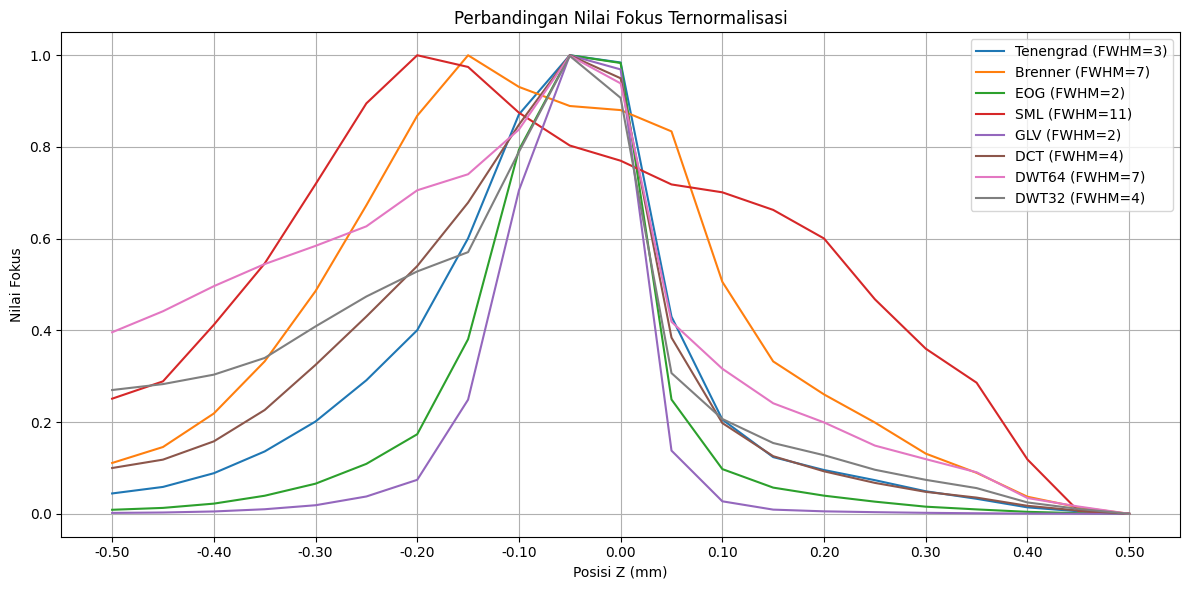

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
import pywt

# --- Algoritma Fokus ---
def tenengrad(image):
    sobelx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
    fm = np.sqrt(sobelx**2 + sobely**2)
    return np.mean(fm**2)

def brenner(image, shift=-2, axis=1):
    fm = image[:, 2:] - image[:, :-2]  # horizontal fixed-shift
    return np.mean(fm**2)

def SML(image):
    Lx = np.abs(image[:, 2:] - 2 * image[:, 1:-1] + image[:, :-2])
    Ly = np.abs(image[2:, :] - 2 * image[1:-1, :] + image[:-2, :])
    sml_map = np.zeros_like(image, dtype=np.float32)
    sml_map[1:-1, 1:-1] = Lx[1:-1, :] + Ly[:, 1:-1]
    return np.mean(sml_map**2)

def EOG(image):
    dx = image[:, 1:] - image[:, :-1]
    dy = image[1:, :] - image[:-1, :]
    fm = np.zeros_like(image, dtype=np.float32)
    fm[:-1, :-1] = dx[:-1, :]**2 + dy[:, :-1]**2
    return np.mean(fm**2)  # hasil berupa focus map

def GLV(image, window_size=5):
    """Statistical variance-based focus measure"""
    kernel = np.ones((window_size, window_size), np.float32) / (window_size * window_size)
    
    mean = cv2.filter2D(image.astype(np.float32), -1, kernel)
    sqr_mean = cv2.filter2D((image.astype(np.float32))**2, -1, kernel)
    variance = sqr_mean - mean**2
    
    return np.mean(variance**2)

def DCT(image, block_size=8, overlap_ratio=0.5):
    """DCT-based focus measure dengan block processing"""
    height, width = image.shape
    step = max(1, int(block_size * (1 - overlap_ratio)))
    
    focus_map = np.zeros((height, width), dtype=np.float32)
    weight_map = np.zeros((height, width), dtype=np.float32)
    
    for i in range(0, height - block_size + 1, step):
        for j in range(0, width - block_size + 1, step):
            block = image[i:i+block_size, j:j+block_size].astype(np.float32)
            
            # DCT transform
            dct_block = cv2.dct(block)
            
            # AC/DC ratio
            dc_component = np.abs(dct_block[0, 0])
            ac_energy = np.sum(np.abs(dct_block)) - dc_component
            focus_value = ac_energy / (dc_component + 1e-8)
            
            focus_map[i:i+block_size, j:j+block_size] += focus_value
            weight_map[i:i+block_size, j:j+block_size] += 1
    
    weight_map[weight_map == 0] = 1
    normalized_fm = focus_map / weight_map
    return np.mean(normalized_fm**2)

def DWT(image, wavelet='db4', levels=2, window_size=32):
    """Multi-scale wavelet-based focus measure"""
    height, width = image.shape
    step = window_size // 2
    
    focus_map = np.zeros((height, width), dtype=np.float32)
    weight_map = np.zeros((height, width), dtype=np.float32)
    
    for i in range(0, height - window_size + 1, step):
        for j in range(0, width - window_size + 1, step):
            window = image[i:i+window_size, j:j+window_size].astype(np.float32)
            
            try:
                coeffs = pywt.wavedec2(window, wavelet, level=levels)
                
                total_detail_energy = 0
                total_approx_energy = np.sum(coeffs[0]**2)
                
                for level in range(1, len(coeffs)):
                    cH, cV, cD = coeffs[level]
                    level_energy = np.sum(cH**2) + np.sum(cV**2) + np.sum(cD**2)
                    weight = 2**(level-1)
                    total_detail_energy += weight * level_energy
                
                total_energy = total_detail_energy + total_approx_energy
                focus_value = total_detail_energy / (total_energy + 1e-8)
                
            except:
                focus_value = 0
            
            focus_map[i:i+window_size, j:j+window_size] += focus_value
            weight_map[i:i+window_size, j:j+window_size] += 1
    
    weight_map[weight_map == 0] = 1
    normalized_fm = focus_map / weight_map
    return np.mean(normalized_fm**2)

# --- FWHM ---
def hitung_fwhm(y_vals):
    y = np.array(y_vals)
    x = np.arange(len(y))
    y_norm = y / np.max(y)
    half_max = 0.5

    indices = np.where(y_norm >= half_max)[0]
    if len(indices) < 2:
        return 0  # Tidak bisa hitung FWHM
    fwhm = indices[-1] - indices[0]
    return fwhm

# --- Proses Semua Gambar ---
def proses_folder(folder_path):
    file_list = sorted([f for f in os.listdir(folder_path) if f.lower().endswith('.jpg')])
    fokus_tenengrad, fokus_brenner, fokus_SML, fokus_EOG, fokus_GLV, fokus_DCT, fokus_DWT64, fokus_DWT32 = [], [], [], [], [], [], [], []

    for file in file_list:
        path = os.path.join(folder_path, file)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        
        print("Tenengrad...")
        fokus_tenengrad.append(tenengrad(img))
        print("Brenner...")
        fokus_brenner.append(brenner(img))
        print("SML...")
        fokus_SML.append(SML(img))
        print("EOG...")
        fokus_EOG.append(EOG(img))
        print("GLV...")
        fokus_GLV.append(GLV(img))
        print("DCT...")
        fokus_DCT.append(DCT(img))
        print("DWT64...")
        fokus_DWT64.append(DWT(img, wavelet='db4', levels=3, window_size=64))
        print("DWT32...")
        fokus_DWT32.append(DWT(img, wavelet='db4', levels=2, window_size=32))


    return {
        'Tenengrad': fokus_tenengrad,
        'Brenner': fokus_brenner,
        'EOG':fokus_EOG,
        'SML':fokus_SML,
        'GLV':fokus_GLV,
        'DCT':fokus_DCT,
        'DWT64':fokus_DWT64,
        'DWT32':fokus_DWT32
    }

# --- Normalisasi ---
def normalisasi(data):
    data = np.array(data)
    return (data - np.min(data)) / (np.max(data) - np.min(data) + 1e-8)

# --- Visualisasi ---
def plot_semua(data_dict):
    plt.figure(figsize=(12, 6))
    for nama, nilai in data_dict.items():
        norm = normalisasi(nilai)
        fwhm = hitung_fwhm(norm)
        plt.plot(norm, label=f"{nama} (FWHM={fwhm})")

    plt.xlabel("Posisi Z (mm)")
    plt.ylabel("Nilai Fokus")
    plt.title("Perbandingan Nilai Fokus Ternormalisasi")
    plt.xticks([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20], labels=['-0.50', '-0.40', '-0.30', '-0.20', '-0.10', '0.00', '0.10', '0.20', '0.30', '0.40', '0.50'])
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --- Main ---
if __name__ == "__main__":
    folder = 'Captures/data_3040/FM_Test'
    if not os.path.isdir(folder):
        print(f"Folder tidak ditemukan: {folder}")
    else:
        hasil = proses_folder(folder)
        plot_semua(hasil)


In [ ]:
import os
import numpy as np
from skimage import io, img_as_float
from skimage.metrics import structural_similarity as ssim
from skimage.util import view_as_windows
from scipy.stats import entropy

# --- UTILITY FUNCTIONS ---

def load_images_from_folder(folder_path):
    images = []
    file_names = sorted([f for f in os.listdir(folder_path) if f.lower().endswith(('png', 'jpg', 'jpeg', 'bmp', 'tif', 'tiff'))])
    for file in file_names:
        img = img_as_float(io.imread(os.path.join(folder_path, file)))
        if img.ndim == 3:  # Convert to grayscale if RGB
            img = img.mean(axis=2)
        images.append(img)
    return images, file_names

def normalize_hist(img):
    hist, _ = np.histogram(img.flatten(), bins=256, range=[0,1], density=True)
    return hist + 1e-12  # Add epsilon for stability

# --- Q_MI: Normalized Mutual Information ---
def mutual_information(img1, img2, bins=256):
    hgram, _, _ = np.histogram2d(img1.flatten(), img2.flatten(), bins=bins, range=[[0,1],[0,1]], density=True)
    pxy = hgram + 1e-12
    px = pxy.sum(axis=1)
    py = pxy.sum(axis=0)
    h_x = entropy(px, base=2)
    h_y = entropy(py, base=2)
    h_xy = entropy(pxy.flatten(), base=2)
    mi = h_x + h_y - h_xy
    return mi, h_x, h_y

def normalized_mi(fused, sources):
    nmi_list = []
    for src in sources:
        mi, h_src, h_fused = mutual_information(src, fused)
        nmi = 2 * mi / (h_src + h_fused)
        nmi_list.append(nmi)
    return np.mean(nmi_list)

# --- Q_SF: Spatial Frequency ---
def row_frequency(img):
    return np.sqrt(np.mean((img[:, 1:] - img[:, :-1])**2))

def col_frequency(img):
    return np.sqrt(np.mean((img[1:, :] - img[:-1, :])**2))

def main_diag_frequency(img):
    return np.sqrt((1/np.sqrt(2)) * np.mean((img[1:, 1:] - img[:-1, :-1])**2))

def sec_diag_frequency(img):
    return np.sqrt((1/np.sqrt(2)) * np.mean((img[1:, :-1] - img[:-1,1:])**2))

def spatial_frequency(img):
    rf = row_frequency(img)
    cf = col_frequency(img)
    mdf = main_diag_frequency(img)
    sdf = sec_diag_frequency(img)
    return np.sqrt(rf**2 + cf**2 + mdf**2 + sdf**2)

def Q_SF(fused, sources):
    sf_fused = spatial_frequency(fused)
    sf_refs = [spatial_frequency(src) for src in sources]
    sf_ref = max(sf_refs)  # max or mean
    return (sf_fused - sf_ref) / (sf_ref if sf_ref != 0 else 1e-12)

# --- Q_W: Local Weighted SSIM (Piella’s Metric, Q_S) ---
def local_variance(img, window_size):
    pad = window_size // 2
    padded = np.pad(img, pad, mode='reflect')
    windows = view_as_windows(padded, (window_size, window_size))
    means = np.mean(windows, axis=(2,3))
    vars = np.mean((windows - means[:,:,None,None])**2, axis=(2,3))
    return vars

def Q_S(fused, sources, window_size=8):
    total_windows = 0
    weighted_sum = 0
    for i in range(0, fused.shape[0] - window_size + 1, window_size):
        for j in range(0, fused.shape[1] - window_size + 1, window_size):
            fused_win = fused[i:i+window_size, j:j+window_size]
            variances = []
            ssims = []
            for src in sources:
                src_win = src[i:i+window_size, j:j+window_size]
                var = np.var(src_win)
                variances.append(var)
                # s = ssim(fused_win, src_win, data_range=src_win.max()-src_win.min())
                s = ssim(fused_win, src_win, data_range=1.0)
                ssims.append(s)
            variances = np.array(variances)
            # Saliency weight
            sal_weight = variances / np.sum(variances) if variances.sum() != 0 else np.ones_like(variances) / len(variances)
            window_score = np.sum(sal_weight * np.array(ssims))
            weighted_sum += window_score
            total_windows += 1
    return weighted_sum / total_windows if total_windows != 0 else 0

In [2]:
if __name__ == "__main__":
    source_folder = 'Captures/data/SCAN_NYMK_3x4_3_40%/TestFS_1.00_-1.00/RAW'   # Folder tempat gambar sumber berada
    fused_path = 'Captures/data/SCAN_NYMK_3x4_3_40%/TestFS_1.00_-1.00/DWT32.jpg'     # Path gambar hasil fusion

    fused = img_as_float(io.imread(fused_path))
    if fused.ndim == 3:
        fused = fused.mean(axis=2)
    sources, file_names = load_images_from_folder(source_folder)
    print('Membaca {} gambar sumber: {}'.format(len(file_names), file_names))

    # Q_MI
    q_mi = normalized_mi(fused, sources)
    print('Q_MI (rata-rata normalized mutual information):', q_mi)

    # Q_SF
    q_sf = Q_SF(fused, sources)
    print('Q_SF (rasio spatial frequency):', q_sf)

    # Q_W (Piella’s Q_S)
    q_s = Q_S(fused, sources, window_size=8)
    print('Q_W / Q_S (weighted local SSIM fusion):', q_s)

Membaca 20 gambar sumber: ['213_1.00_-1.00_-1.00.jpg', '214_1.00_-1.00_-0.80.jpg', '215_1.00_-1.00_-0.60.jpg', '216_1.00_-1.00_-0.40.jpg', '217_1.00_-1.00_-0.20.jpg', '218_1.00_-1.00_0.00.jpg', '219_1.00_-1.00_0.20.jpg', '220_1.00_-1.00_0.40.jpg', '221_1.00_-1.00_0.60.jpg', '222_1.00_-1.00_0.80.jpg', '223_1.00_-1.00_1.00.jpg', '224_1.00_-1.00_1.20.jpg', '225_1.00_-1.00_1.40.jpg', '226_1.00_-1.00_1.60.jpg', '227_1.00_-1.00_1.80.jpg', '228_1.00_-1.00_2.00.jpg', '229_1.00_-1.00_2.20.jpg', '230_1.00_-1.00_2.40.jpg', '231_1.00_-1.00_2.60.jpg', '232_1.00_-1.00_2.80.jpg']
Q_MI (rata-rata normalized mutual information): 0.2796632833015242
Q_SF (rasio spatial frequency): 1.670566749111737
Q_W / Q_S (weighted local SSIM fusion): 0.8768363146646233
